In [1]:

import argparse
import glob
import os
import re
import sys
import time
from datetime import datetime
from pathlib import Path
import pickle
import sys
from pathlib import Path

import xarray as xr

import numpy as np
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cmc
 

sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import utils
import plot_utils

plt.style.use("../plotstyling.mplstyle")

In [2]:


pairs_file = "../data/earthcare_aws_file_pairs_2026-06.pkl"
pair_index = 0              # which collocation in the file to use

with open(pairs_file, "rb") as f:
    pairs = pickle.load(f)
print(f"{len(pairs)} collocations in {pairs_file}")

aws_path, ea_path = pairs[pair_index]
print("AWS:      ", Path(aws_path).name)
print("EarthCARE:", Path(ea_path).name)

# matched AWS pixels and EarthCARE profiles, as in batch_plot_collocations.py
col = utils.colocate_pair_nearest_profile(aws_path, ea_path, max_dist_km=5.0)
print(f"{col['scan'].size} matched AWS pixels")

117 collocations in ../data/earthcare_aws_file_pairs_2026-06.pkl
AWS:       l2_arctic_20260601010803_20260601024725_v2.nc
EarthCARE: ECA_EXBC_ACM_CAP_2B_20260601T013123Z_20260601T032906Z_11407C.h5
112 matched AWS pixels


In [3]:
aws = utils.load_aws(aws_path, start=0, end=400)
ea = utils.load_earthcare(ea_path)

In [4]:
max_dist_km = 15.0
KM_PER_DEG = 111.2

# restrict earthcare points to the aws swath so we have fewer to search
in_box = (
    (ea["lon"] >= np.nanmin(aws["lon"]))
    & (ea["lon"] <= np.nanmax(aws["lon"]))
    & (ea["lat"] >= np.nanmin(aws["lat"]))
    & (ea["lat"] <= np.nanmax(aws["lat"]))
)
ea_idx = np.flatnonzero(in_box)
ea_lon = ea["lon"][ea_idx]
ea_lat = ea["lat"][ea_idx]

out = {"lat": [], "lon": [], "scan": [], "aws_fwp": [], "ea_iwp": [],
       "ea_iwc": [], "aws_lwp": [], "ea_lwp": [], "ea_lwc": [],
       "aws_fwp_q1": [], "aws_fwp_q16": [], "aws_fwp_q84": [], "aws_fwp_q99": [],
       "aws_lwp_q1": [], "aws_lwp_q16": [], "aws_lwp_q84": [], "aws_lwp_q99": [],
       "aws_zm": [], "ea_zm": [],
       "ea_height": [], "dist_km": []}

if ea_idx.size > 0:

    # we want all points within 15km, which we convert to a latitude distance instead
    lat_margin = max_dist_km / KM_PER_DEG

    # we've limited earthcare to a rectangular area corresponding to the aws swath bounds.
    # we now limit the aws samples to a band surrounding these earthcare samples.
    candidates = np.flatnonzero(
        (aws["lat"] >= np.nanmin(ea_lat) - lat_margin)
        & (aws["lat"] <= np.nanmax(ea_lat) + lat_margin)
        & np.isfinite(aws["fwp"])
    )

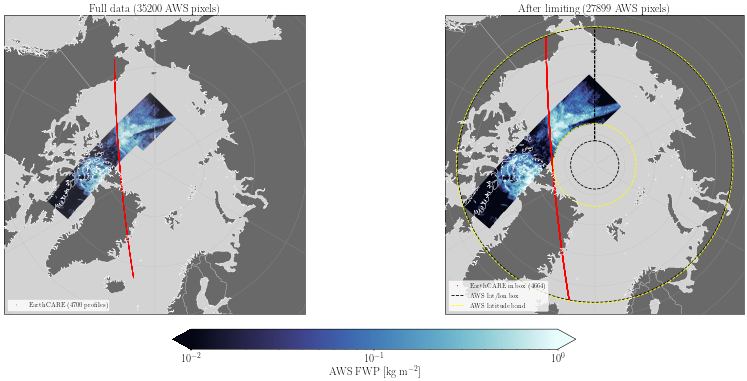

In [5]:
def style_map(ax, scale="50m"):
    """Same look as the collocation maps, at a fixed level of detail."""
    ax.add_feature(cfeature.OCEAN.with_scale(scale), facecolor="lightgrey", zorder=0)
    ax.add_feature(cfeature.LAND.with_scale(scale), facecolor="dimgrey", zorder=0)
    ax.add_feature(cfeature.BORDERS.with_scale(scale), edgecolor="white", linewidth=0.5, zorder=1)
    ax.coastlines(resolution=scale, color="white", linewidth=0.8, zorder=10)
    ax.gridlines(draw_labels=False, linewidth=0.3)

fwp_norm = LogNorm(vmin=1e-2, vmax=1e0)
geo = ccrs.PlateCarree()

fig, (ax_full, ax_lim) = plt.subplots(
    1, 2, figsize=(26, 12), subplot_kw={"projection": ccrs.NorthPolarStereo()}
)

# ---- full AWS swath and full EarthCARE track ----
ax = ax_full
style_map(ax)
ax.set_extent([-180, 180, 60, 90], crs=geo)
sc = ax.scatter(aws["lon"], aws["lat"], c=aws["fwp"], s=1, ec="none",
                norm=fwp_norm, cmap=cmc.cm.ice, transform=geo, zorder=2)
ax.scatter(ea["lon"], ea["lat"], c="red", s=2, ec="none", transform=geo, zorder=3,
           label=f"EarthCARE ({ea['lon'].size} profiles)")
ax.legend(loc="lower left", fontsize=12)
ax.set_title(f"Full data ({aws['lon'].size} AWS pixels)")

# ---- after limiting both ----
ax = ax_lim
style_map(ax)

# zoom in on the AWS lat/lon box, with a little room around it
lon_lo, lon_hi = np.nanmin(aws["lon"]), np.nanmax(aws["lon"])
lat_lo, lat_hi = np.nanmin(aws["lat"]), np.nanmax(aws["lat"])
ax.set_extent([lon_lo, lon_hi, max(lat_lo - 2, 50), min(lat_hi + 2, 90)], crs=geo)

ax.scatter(aws["lon"][candidates], aws["lat"][candidates], c=aws["fwp"][candidates],
           s=4, ec="none", norm=fwp_norm, cmap=cmc.cm.ice, transform=geo, zorder=2)
ax.scatter(ea_lon, ea_lat, c="red", s=4, ec="none", transform=geo, zorder=3,
           label=f"EarthCARE in box ({ea_lon.size})")

# outline of the AWS lat/lon box used to limit EarthCARE
edge_lon = np.linspace(lon_lo, lon_hi, 200)
edge_lat = np.linspace(lat_lo, lat_hi, 200)
box_lon = np.concatenate([edge_lon, np.full(200, lon_hi), edge_lon[::-1], np.full(200, lon_lo)])
box_lat = np.concatenate([np.full(200, lat_lo), edge_lat, np.full(200, lat_hi), edge_lat[::-1]])
ax.plot(box_lon, box_lat, color="black", ls="--", lw=1.5, transform=geo, zorder=4,
        label="AWS lat/lon box")

# latitude band used to limit AWS: lines of constant latitude, all the way round
band_lon = np.linspace(-180, 180, 721)
for i, band_lat in enumerate([np.nanmin(ea_lat) - lat_margin, np.nanmax(ea_lat) + lat_margin]):
    ax.plot(band_lon, np.full_like(band_lon, band_lat), color="yellow", ls="--", lw=1.5,
            transform=geo, zorder=4, label="AWS latitude band" if i == 0 else None)

ax.legend(loc="lower left", fontsize=12)
ax.set_title(f"After limiting ({candidates.size} AWS pixels)")

fig.colorbar(sc, ax=[ax_full, ax_lim], orientation="horizontal", shrink=0.5, pad=0.04,
             extend="both", label=r"AWS FWP [kg m$^{-2}$]")
plt.show()

In [6]:
matched_aws = []    # index of each matched AWS pixel
matched_ea = []     # index of its nearest EarthCARE profile
matched_dist = []   # distance between them [km]

for j in candidates:
    dlat = ea_lat - aws["lat"][j]
    near = np.flatnonzero(np.abs(dlat) * KM_PER_DEG <= max_dist_km)
    if near.size == 0:
        continue

    dlon = ea_lon[near] - aws["lon"][j]
    dlon = (dlon + 180.0) % 360.0 - 180.0
    dx = dlon * np.cos(np.deg2rad(aws["lat"][j])) * KM_PER_DEG
    dy = dlat[near] * KM_PER_DEG
    d = np.sqrt(dx * dx + dy * dy)

    i = np.argmin(d)
    if d[i] > max_dist_km:
        continue
    p = ea_idx[near[i]]

    matched_aws.append(j)
    matched_ea.append(p)
    matched_dist.append(d[i])

matched_aws = np.array(matched_aws, dtype=int)
matched_ea = np.array(matched_ea, dtype=int)
matched_dist = np.array(matched_dist)
used_ea = np.unique(matched_ea)   # each EarthCARE profile once, even if several pixels chose it

print(f"{matched_aws.size} of {candidates.size} candidate AWS pixels matched")
print(f"{used_ea.size} different EarthCARE profiles used")

331 of 27899 candidate AWS pixels matched
282 different EarthCARE profiles used


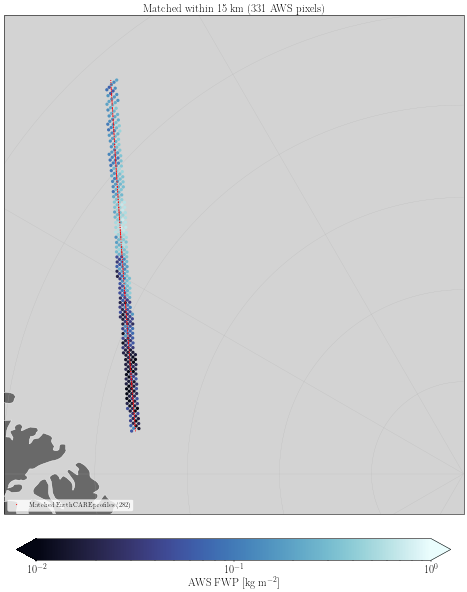

In [20]:
fig, ax = plt.subplots(figsize=(20, 20), subplot_kw={"projection": ccrs.NorthPolarStereo()})
style_map(ax)
ax.set_extent([-174, -85, 80, 90], crs=geo)

sc = ax.scatter(aws["lon"][matched_aws], aws["lat"][matched_aws], c=aws["fwp"][matched_aws],
                s=35, ec="none", norm=fwp_norm, cmap=cmc.cm.ice, transform=geo, zorder=2)
ax.scatter(ea["lon"][used_ea], ea["lat"][used_ea], c="red", s=4, ec="none",
           transform=geo, zorder=3, label=f"Matched EarthCARE profiles ({used_ea.size})")

ax.legend(loc="lower left", fontsize=12)
ax.set_title(f"Matched within {max_dist_km:g} km ({matched_aws.size} AWS pixels)")
fig.colorbar(sc, ax=ax, orientation="horizontal", shrink=0.7, pad=0.04,
             extend="both", label=r"AWS FWP [kg m$^{-2}$]")

In [21]:
# ---- one pixel per scan: keep the closest match in each AWS scan ----
scan = aws["scan"][matched_aws]          # scan time of each matched pixel

# sort by scan time, and within each scan by distance (closest first)
order = np.lexsort((matched_dist, scan))
scan_sorted = scan[order]

# the first entry of each scan in this order is its closest match
first_in_scan = np.r_[True, scan_sorted[1:] != scan_sorted[:-1]]
keep = order[first_in_scan]

matched_aws = matched_aws[keep]
matched_ea = matched_ea[keep]
matched_dist = matched_dist[keep]
used_ea = np.unique(matched_ea)

print(f"{matched_aws.size} AWS pixels left, one per scan")
print(f"{used_ea.size} different EarthCARE profiles used")

72 AWS pixels left, one per scan
72 different EarthCARE profiles used


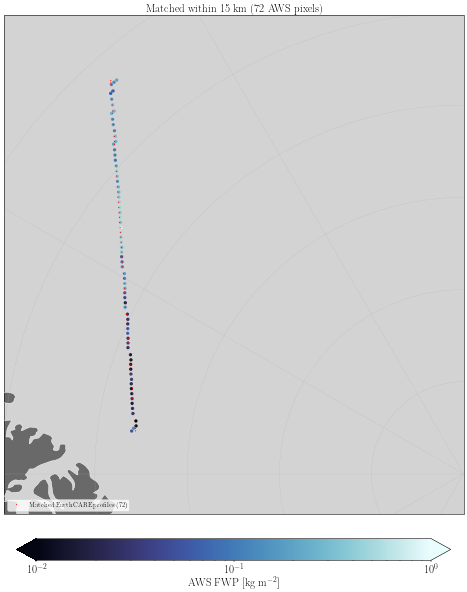

In [22]:
fig, ax = plt.subplots(figsize=(20, 20), subplot_kw={"projection": ccrs.NorthPolarStereo()})
style_map(ax)
ax.set_extent([-174, -85, 80, 90], crs=geo)

sc = ax.scatter(aws["lon"][matched_aws], aws["lat"][matched_aws], c=aws["fwp"][matched_aws],
                s=35, ec="none", norm=fwp_norm, cmap=cmc.cm.ice, transform=geo, zorder=2)
ax.scatter(ea["lon"][used_ea], ea["lat"][used_ea], c="red", s=4, ec="none",
           transform=geo, zorder=3, label=f"Matched EarthCARE profiles ({used_ea.size})")

ax.legend(loc="lower left", fontsize=12)
ax.set_title(f"Matched within {max_dist_km:g} km ({matched_aws.size} AWS pixels)")
fig.colorbar(sc, ax=ax, orientation="horizontal", shrink=0.7, pad=0.04,
             extend="both", label=r"AWS FWP [kg m$^{-2}$]")

In [24]:
xr.open_dataset(aws_path)

<xarray.Dataset> Size: 19MB
Dimensions:                 (scan: 944, fov: 88, quantile: 5, surface_type: 6,
                             channel: 19)
Coordinates:
  * scan                    (scan) datetime64[ns] 8kB 2026-06-01T01:08:04.913...
  * quantile                (quantile) float32 20B 0.02 0.16 0.5 0.84 0.98
  * surface_type            (surface_type) <U7 168B 'ocean' ... 'glacier'
  * channel                 (channel) <U5 380B 'AWS11' 'AWS12' ... 'AWS44'
    latitude                (scan, fov) float32 332kB ...
    longitude               (scan, fov) float32 332kB ...
Dimensions without coordinates: fov
Data variables: (12/18)
    fwp_mean                (scan, fov) float32 332kB ...
    fwp_most_prob           (scan, fov) float32 332kB ...
    fwp_quantiles           (scan, fov, quantile) float32 2MB ...
    fwp_dm_mean             (scan, fov) float32 332kB ...
    fwp_dm_most_prob        (scan, fov) float32 332kB ...
    fwp_dm_quantiles        (scan, fov, quantile) float32 2MB ...
    ...                      ...
    remap_distance          (scan, fov) float32 332kB ...
    surface_type_fractions  (scan, fov, surface_type) float32 2MB ...
    tb                      (scan, fov, channel) float32 6MB ...
    l1b_index_scans         (scan) uint32 4kB ...
    l1b_index_fovs          (fov) uint32 352B ...
    flag_bad_data           (scan, fov) uint8 83kB ...
Attributes:
    title:        CHIP-AWS: Arctic retrievals
    institution:  Chalmers University of Technology
    references:   n/a
    history:      Retrieval processing